In [4]:
import pandas as pd

df = pd.read_csv("SocialMedia.csv")

df.head()


,flagCode,country,SocialMediaUsers_2025,SocialMediaUsersPctOfPopulation_2025
0,CN,China,1280000000,90.3
1,IN,India,500000000,34.1
2,US,United States,254000000,73.0
3,ID,Indonesia,180000000,62.9
4,BR,Brazil,150000000,70.4


In [5]:
print(df.shape)
print(df.columns)
print(df.info())

(231, 4)
Index(['flagCode', 'country', 'SocialMediaUsers_2025',
       'SocialMediaUsersPctOfPopulation_2025'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   flagCode                              229 non-null    object 
 1   country                               231 non-null    object 
 2   SocialMediaUsers_2025                 231 non-null    int64  
 3   SocialMediaUsersPctOfPopulation_2025  230 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 7.3+ KB
None


In [6]:
top_users = df.sort_values(
    "SocialMediaUsers_2025",
    ascending=False
).head(10)

print(top_users[["country","SocialMediaUsers_2025"]])

           country  SocialMediaUsers_2025
230          Total             4688590350
0            China             1280000000
1            India              500000000
2    United States              254000000
3        Indonesia              180000000
4           Brazil              150000000
5           Russia              106000000
6           Mexico               99000000
7            Japan               99000000
8      Philippines               95800000


In [8]:
top_pct = df.sort_values(
    "SocialMediaUsersPctOfPopulation_2025",
    ascending=False
).head(10)

print(top_pct[["country","SocialMediaUsersPctOfPopulation_2025"]])

                  country  SocialMediaUsersPctOfPopulation_2025
25           Saudi Arabia                                 111.0
50   United Arab Emirates                                 110.0
19            South Korea                                  95.4
110                 Qatar                                  94.3
216          Cook Islands                                  90.9
81              Singapore                                  90.6
0                   China                                  90.3
73                  Libya                                  89.6
115             Lithuania                                  89.5
90                 Kuwait                                  87.9


In [9]:
def category(x):
    if x >= 80:
        return "Very High Adoption"
    elif x >= 60:
        return "High Adoption"
    elif x >= 40:
        return "Moderate Adoption"
    else:
        return "Low Adoption"

df["AdoptionLevel"] = df[
    "SocialMediaUsersPctOfPopulation_2025"
].apply(category)

print(df.head())

  flagCode        country  SocialMediaUsers_2025  \
0       CN          China             1280000000   
1       IN          India              500000000   
2       US  United States              254000000   
3       ID      Indonesia              180000000   
4       BR         Brazil              150000000   

   SocialMediaUsersPctOfPopulation_2025       AdoptionLevel  
0                                  90.3  Very High Adoption  
1                                  34.1        Low Adoption  
2                                  73.0       High Adoption  
3                                  62.9       High Adoption  
4                                  70.4       High Adoption  


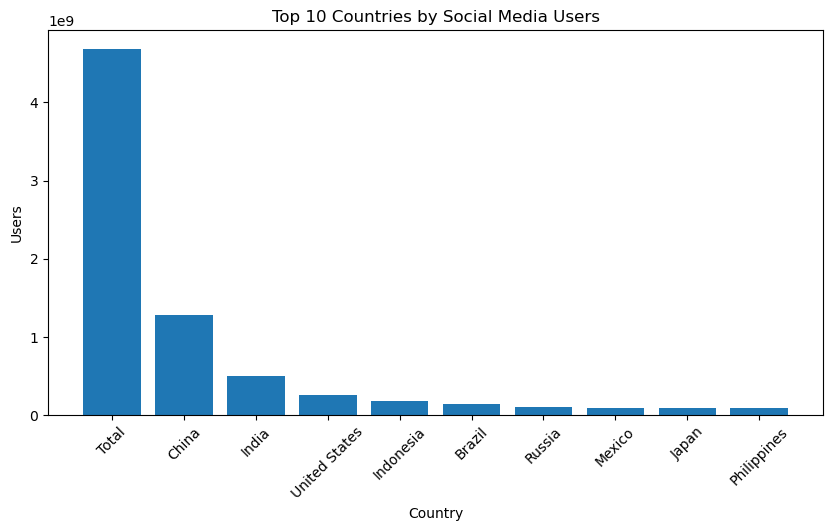

In [11]:
import matplotlib.pyplot as plt

top10 = df.sort_values(
    "SocialMediaUsers_2025",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["country"],
    top10["SocialMediaUsers_2025"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Social Media Users")

plt.xlabel("Country")
plt.ylabel("Users")

plt.show()

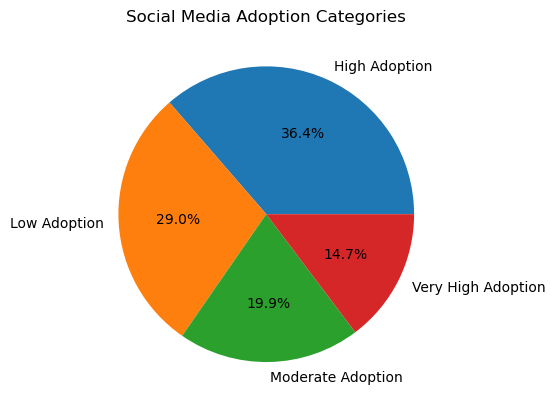

In [12]:
df["AdoptionLevel"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Social Media Adoption Categories")
plt.ylabel("")

plt.show()

In [13]:
low = df[
    df["SocialMediaUsersPctOfPopulation_2025"] < 40
]

print(low[
    ["country",
     "SocialMediaUsersPctOfPopulation_2025"]
])

               country  SocialMediaUsersPctOfPopulation_2025
1                India                                  34.1
9             Pakistan                                  31.2
11             Mayotte                                  23.2
13          Bangladesh                                  36.3
21             Nigeria                                  20.0
..                 ...                                   ...
222         San Marino                                  21.6
224             Tuvalu                                  37.5
225  Wallis and Futuna                                  26.0
227         Montserrat                                  39.1
228            Tokelau                                  39.9

[66 rows x 2 columns]


In [18]:
df2 = df[df['country'] != 'Total']

highest_users = df2.loc[df2['SocialMediaUsers_2025'].idxmax()]

print("Highest Users Country:")
print(highest_users['country'])

print("Total Users:")
print(highest_users['SocialMediaUsers_2025'])

Highest Users Country:
China
Total Users:
1280000000


In [17]:
highest_pct = df.loc[
    df['SocialMediaUsersPctOfPopulation_2025'].idxmax()
]

print("Highest Adoption Country:")
print(highest_pct['country'])

print("Adoption Percentage:")
print(highest_pct['SocialMediaUsersPctOfPopulation_2025'])

Highest Adoption Country:
Saudi Arabia
Adoption Percentage:
111.0
